# 06 · Question quality (Gemini 3.0 Pro, general run)

Two checks on the 7,770 general questions (five per detection):

- **Semantic diversity:** are the five questions for one photo really different, or the same idea reworded? Each set is embedded with a sentence transformer (all-MiniLM-L6-v2). Diversity = 1 minus the mean pairwise cosine similarity within the set, computed on a sample of 30 photos per amenity.
- **Length:** questions have to fit into a UI and be read at a glance. 10 to 20 words is the target range.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from amenity_qgen import config, plotting
from amenity_qgen.plotting import SERIES, MUTED, TEXT, TEXT_2

plotting.use_style()
pd.set_option("display.max_colwidth", 120)
FIG = ROOT / "results" / "figures"
AMENITIES = ["bathtub", "kettle", "hairdryer", "mirror", "tv"]
NAMES = {"bathtub": "Bathtub", "kettle": "Kettle", "hairdryer": "Hairdryer", "mirror": "Mirror", "tv": "TV"}

,mean_similarity,mean_semantic_diversity
amenity,,
Bathtub,0.285,0.715
Kettle,0.316,0.684
Hairdryer,0.191,0.809
Mirror,0.372,0.628
TV,0.292,0.708


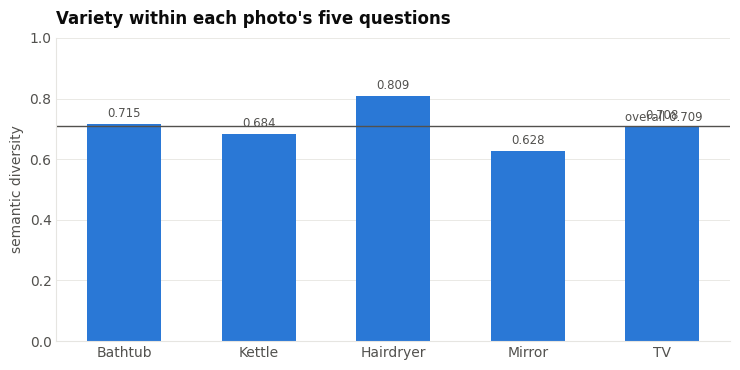

In [2]:
RUN_EMBEDDINGS = False   # needs sentence-transformers
if RUN_EMBEDDINGS:
    from amenity_qgen.quality import load_encoder, semantic_diversity
    encoder = load_encoder()

div = pd.read_csv(ROOT / "results" / "generation" / "semantic_diversity.csv").set_index("amenity").loc[AMENITIES]
overall = div.mean_semantic_diversity.mean()
display(div.rename(index=NAMES).round(3))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
bars = ax.bar([NAMES[a] for a in AMENITIES], div.mean_semantic_diversity, color=SERIES[0], width=0.55)
plotting.label_bars(ax, bars, "{:.3f}")
ax.axhline(overall, color=TEXT_2, lw=1)
ax.annotate(f"overall {overall:.3f}", (4.3, overall), xytext=(0, 4), textcoords="offset points", ha="right", fontsize=8.5, color=TEXT_2)
ax.set_ylim(0, 1); ax.set_ylabel("semantic diversity"); ax.set_title("Variety within each photo's five questions"); ax.grid(axis="x", visible=False)
plt.tight_layout(); fig.savefig(FIG / "quality_diversity.png"); plt.show()

Hairdryer questions are the most varied (heat settings, wall mount, cord length, attachments). Mirror has the fewest things you can ask about from a photo, so its questions overlap more.

,mean,std,min,max
amenity,,,,
Bathtub,12.1,2.2,7.0,20.0
Kettle,13.2,2.6,4.0,23.0
Hairdryer,11.9,2.3,6.0,27.0
Mirror,15.3,2.5,2.0,34.0
TV,14.5,3.1,8.0,35.0
Overall,13.9,2.9,2.0,35.0


93.3% of questions are 10 to 20 words long


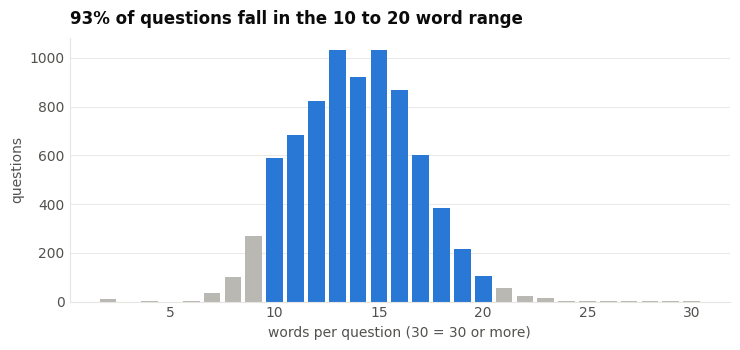

In [3]:
lengths = []
for am in AMENITIES:
    d = pd.read_csv(ROOT / "results" / "generation" / f"questions_{am}_all_models.csv")
    for i in range(1, 6):
        lengths += [(am, len(q.split())) for q in d[f"3_pro_preview_question_{i}"].dropna()]
L = pd.DataFrame(lengths, columns=["amenity", "words"])
stats = L.groupby("amenity").words.agg(["mean", "std", "min", "max"]).loc[AMENITIES].rename(index=NAMES)
stats.loc["Overall"] = [L.words.mean(), L.words.std(), L.words.min(), L.words.max()]
display(stats.round(1))
in_range = L.words.between(10, 20).mean()
print(f"{in_range:.1%} of questions are 10 to 20 words long")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
counts = L.words.clip(upper=30).value_counts().sort_index()
ax.bar(counts.index, counts.values, color=[SERIES[0] if 10 <= w <= 20 else MUTED for w in counts.index], width=0.8)
ax.set_xlabel("words per question (30 = 30 or more)"); ax.set_ylabel("questions")
ax.set_title(f"{in_range:.0%} of questions fall in the 10 to 20 word range"); ax.grid(axis="x", visible=False)
plt.tight_layout(); fig.savefig(FIG / "quality_length.png"); plt.show()

## Takeaways
- Mean semantic diversity is 0.709, so the five questions for a photo cover different concerns rather than repeating one.
- Questions average about 14 words and stay short enough for a UI. Mirror questions run longest, because they often set up the context first, as in *"Since this appears to be a standard flat mirror, is a separate magnifying mirror provided for close-up needs?"*